# 👠 Analisis Dataset Women's Shoes

## 1. Perkenalan Dataset

Dataset ini berasal dari website **Kaggle** dan berisi informasi produk sepatu wanita yang dijual di berbagai toko online di Amerika Serikat.

Terdapat **3 file CSV** yang digunakan:

| File | Deskripsi | Jumlah Baris (raw) | Kolom |
|---|---|---|---|
| `Datafiniti_Womens_Shoes.csv` | Dataset sepatu wanita (versi lama) | ~9.999 | 34 |
| `Datafiniti_Womens_Shoes_Jun19.csv` | Dataset sepatu wanita (Juni 2019) | ~9.999 | 32 |
| `7210_1.csv` | Dataset produk umum Datafiniti | ~33.801 | 52 |

### Fokus Analisis
Analisis utama berfokus pada **dua file shoes** yang digabungkan menjadi satu DataFrame (`df_shoes`), dengan total sekitar **20.000 baris** dan **31 kolom** sebelum preprocessing.

### Atribut Utama
- **Identitas produk**: `id`, `name`, `brand`, `categories`, `primaryCategories`
- **Harga**: `prices.amountMin`, `prices.amountMax`, `prices.currency`
- **Deskripsi fisik**: `colors`, `sizes`, `dimension`, `weight`
- **Metadata harga**: `prices.availability`, `prices.isSale`, `prices.merchant`, `prices.shipping`
- **Waktu**: `dateAdded`, `dateUpdated`, `prices.dateAdded`, `prices.dateSeen`


## 2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("Library berhasil di-import")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

## 3. Memuat Dataset

In [12]:
# Path file
FILE_1 = 'data/Datafiniti_Womens_Shoes.csv'
FILE_2 = 'data/Datafiniti_Womens_Shoes_Jun19.csv'
FILE_3 = 'data/7210_1.csv'

# Muat masing-masing file
df1 = pd.read_csv(FILE_1)
df2 = pd.read_csv(FILE_2)
df3 = pd.read_csv(FILE_3, low_memory=False)

print("=== Ukuran Dataset ===")
print(f"df1  ({FILE_1:<40}): {df1.shape}")
print(f"df2  ({FILE_2:<40}): {df2.shape}")
print(f"df3  ({FILE_3:<40}): {df3.shape}")


=== Ukuran Dataset ===
df1  (data/Datafiniti_Womens_Shoes.csv        ): (10000, 34)
df2  (data/Datafiniti_Womens_Shoes_Jun19.csv  ): (10000, 32)
df3  (data/7210_1.csv                         ): (33801, 52)


In [13]:
# Gabungkan df1 & df2 berdasarkan kolom yang sama
common_cols = [c for c in df1.columns if c in df2.columns]
print(f"Kolom bersama df1 & df2: {len(common_cols)}")

df_shoes = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)
print(f"Shape df_shoes (gabungan): {df_shoes.shape}")
df_shoes.head(3)


Kolom bersama df1 & df2: 31
Shape df_shoes (gabungan): (20000, 31)


,id,dateAdded,dateUpdated,asins,brand,categories,primaryCategories,colors,dimension,imageURLs,...,prices.dateSeen,prices.isSale,prices.merchant,prices.offer,prices.returnPolicy,prices.shipping,prices.size,prices.sourceURLs,sizes,sourceURLs
0,AVpfEf_hLJeJML431ueH,2015-05-04T12:13:08Z,2018-01-29T04:38:43Z,NaN,Naturalizer,"Clothing,Shoes,Women's Shoes,All Women's Shoes...",Shoes,"Silver,Cream Watercolor Floral",NaN,https://i5.walmartimages.com/asr/861ca6cf-fa55...,...,"2017-03-25T09:19:24.819Z,2017-03-25T09:19:19.600Z",False,Overstock.com,NaN,NaN,NaN,S,https://www.overstock.com/Clothing-Shoes/Women...,"6W,9W,7.5W,12W,8.5M,9N,9M,9.5M,10.5M,10W,8.5W,...",https://www.walmart.com/ip/Naturalizer-Danya-W...
1,AVpi74XfLJeJML43qZAc,2017-01-27T01:23:39Z,2018-01-03T05:21:54Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,Women's Casual Sh...",Shoes,Grey,NaN,https://i5.walmartimages.com/asr/421de5d5-3a74...,...,"2017-12-08T14:24:00.000Z,2017-11-01T02:52:00.000Z",True,Walmart.com,NaN,NaN,Standard,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...
2,AVpi74XfLJeJML43qZAc,2017-01-27T01:23:39Z,2018-01-03T05:21:54Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,Women's Casual Sh...",Shoes,Grey,NaN,https://i5.walmartimages.com/asr/421de5d5-3a74...,...,"2017-11-10T15:11:00.000Z,2017-11-18T08:00:00.000Z",False,Slippers Dot Com,NaN,NaN,Value,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...


## 4. Exploratory Data Analysis (EDA)

### 4.1 Informasi Umum Dataset

In [14]:
print("=== Info DataFrame ===")
df_shoes.info()

=== Info DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   20000 non-null  object 
 1   dateAdded            20000 non-null  object 
 2   dateUpdated          20000 non-null  object 
 3   asins                8 non-null      object 
 4   brand                20000 non-null  object 
 5   categories           20000 non-null  object 
 6   primaryCategories    20000 non-null  object 
 7   colors               12631 non-null  object 
 8   dimension            582 non-null    object 
 9   imageURLs            12643 non-null  object 
 10  keys                 20000 non-null  object 
 11  manufacturer         1889 non-null   object 
 12  manufacturerNumber   3913 non-null   object 
 13  name                 20000 non-null  object 
 14  prices.amountMax     20000 non-null  float64
 15  prices.amount

In [15]:
print("=== Statistik Deskriptif (Numerik) ===")
df_shoes.describe()

=== Statistik Deskriptif (Numerik) ===


,prices.amountMax,prices.amountMin,prices.returnPolicy
count,20000.000000,20000.000000,0.0
mean,70.713133,61.666965,NaN
std,122.687817,123.277582,NaN
min,5.500000,4.880000,NaN
25%,49.950000,37.150000,NaN
50%,59.990000,49.990000,NaN
75%,79.990000,69.950000,NaN
max,5000.000000,5000.000000,NaN


### 4.2 Nilai Hilang (Missing Values)

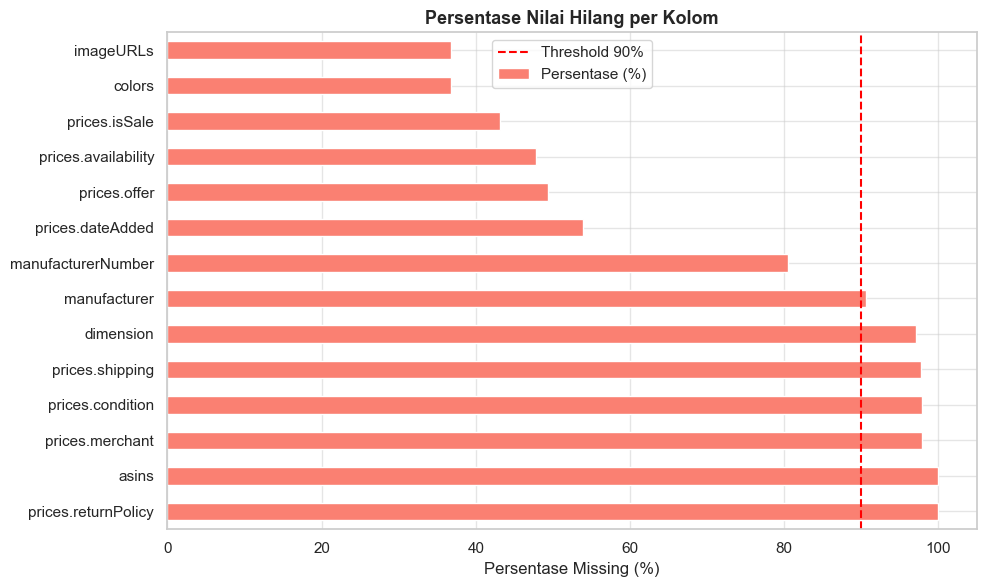

,Jumlah Missing,Persentase (%)
prices.returnPolicy,20000,100.00
asins,19992,99.96
prices.merchant,19565,97.82
prices.condition,19562,97.81
prices.shipping,19539,97.70
dimension,19418,97.09
manufacturer,18111,90.56
manufacturerNumber,16087,80.44
prices.dateAdded,10777,53.89
prices.offer,9879,49.40


In [16]:
missing = df_shoes.isnull().sum()
pct     = (missing / len(df_shoes) * 100).round(2)
miss_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': pct})
miss_df = miss_df[miss_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
miss_df['Persentase (%)'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Nilai Hilang per Kolom', fontsize=13, fontweight='bold')
ax.axvline(90, color='red', linestyle='--', label='Threshold 90%')
ax.legend()
plt.tight_layout()
plt.show()

miss_df

### 4.3 Distribusi Harga

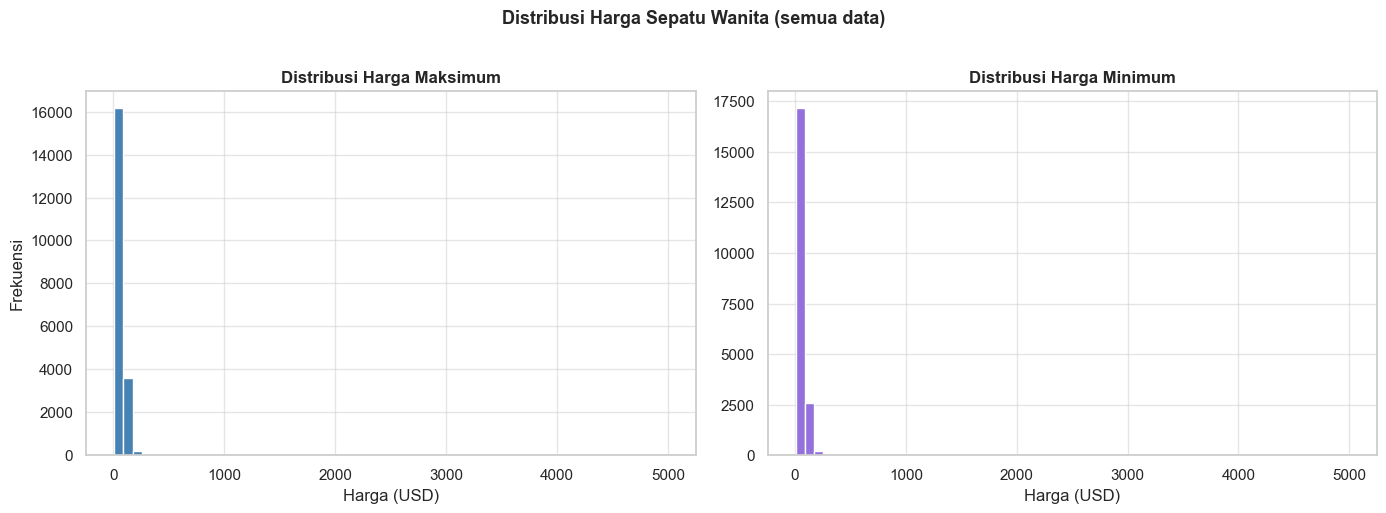

       prices.amountMin  prices.amountMax
count      20000.000000      20000.000000
mean          61.666965         70.713133
std          123.277582        122.687817
min            4.880000          5.500000
25%           37.150000         49.950000
50%           49.990000         59.990000
75%           69.950000         79.990000
max         5000.000000       5000.000000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Harga maks
axes[0].hist(df_shoes['prices.amountMax'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga Maksimum', fontweight='bold')
axes[0].set_xlabel('Harga (USD)')
axes[0].set_ylabel('Frekuensi')

# Harga min
axes[1].hist(df_shoes['prices.amountMin'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
axes[1].set_title('Distribusi Harga Minimum', fontweight='bold')
axes[1].set_xlabel('Harga (USD)')

plt.suptitle('Distribusi Harga Sepatu Wanita (semua data)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_shoes[['prices.amountMin','prices.amountMax']].describe())


### 4.4 Top Brand

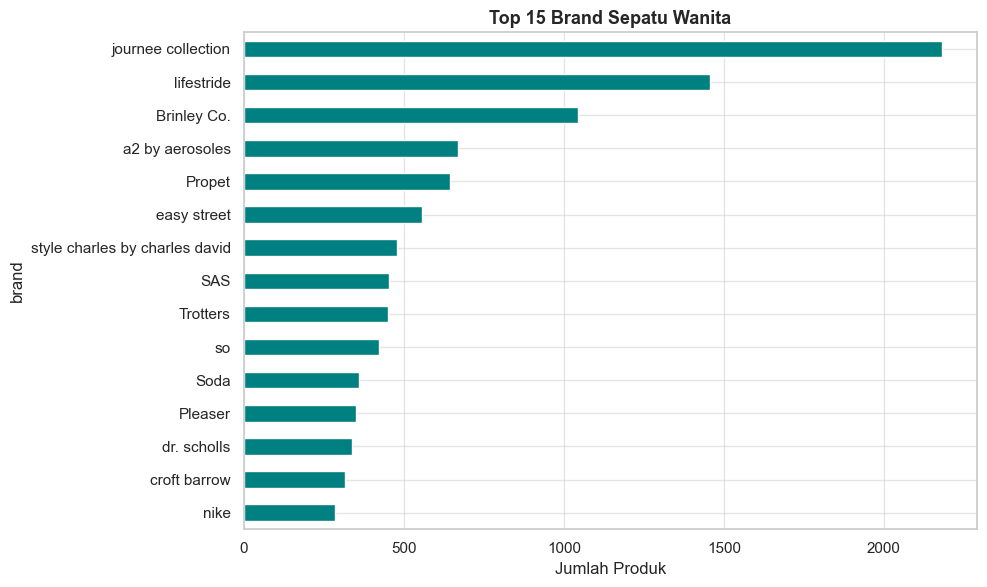

In [18]:
top_brands = df_shoes['brand'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_brands.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 15 Brand Sepatu Wanita', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Produk')
plt.tight_layout()
plt.show()


### 4.5 Proporsi Produk Sale vs Non-Sale

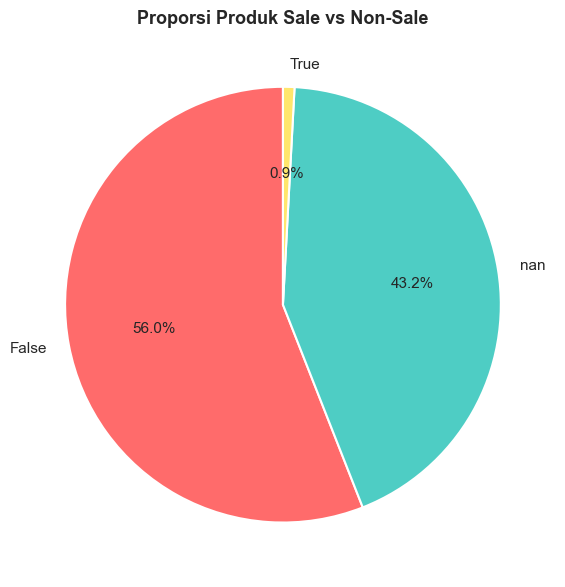

In [19]:
sale_counts = df_shoes['prices.isSale'].value_counts(dropna=False)
labels = sale_counts.index.astype(str).tolist()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sale_counts, labels=labels, autopct='%1.1f%%',
       colors=['#ff6b6b','#4ecdc4','#ffe66d'],
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Proporsi Produk Sale vs Non-Sale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.6 Rata-rata Harga per Brand (Top 10)

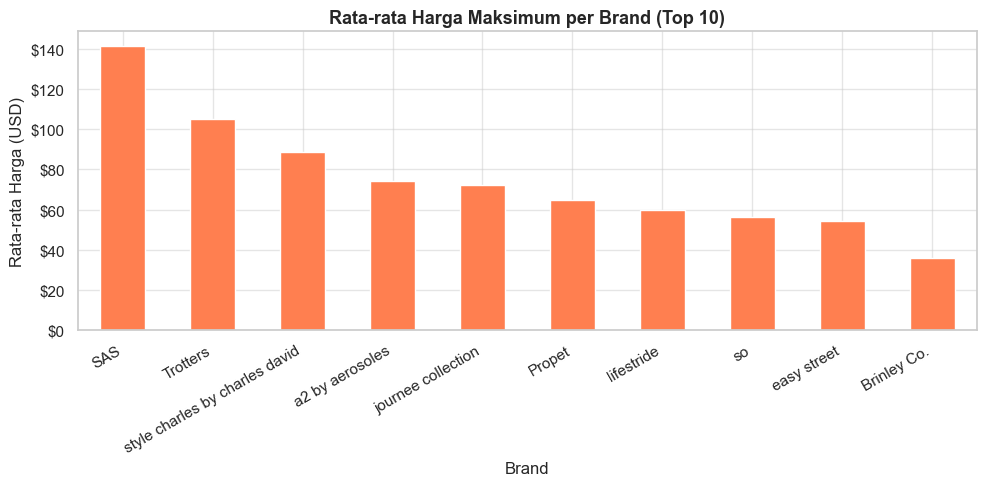

In [20]:
top10_brands = df_shoes['brand'].value_counts().head(10).index
avg_price = (df_shoes[df_shoes['brand'].isin(top10_brands)]
             .groupby('brand')['prices.amountMax']
             .mean()
             .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
avg_price.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Rata-rata Harga Maksimum per Brand (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Rata-rata Harga (USD)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 4.7 Korelasi Harga

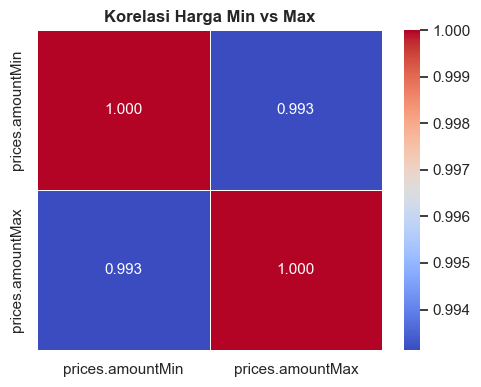

In [21]:
corr = df_shoes[['prices.amountMin','prices.amountMax']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Korelasi Harga Min vs Max', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Data Preprocessing

### 5.1 Hapus Kolom dengan Missing Value > 90%

In [22]:
threshold = 0.90
cols_drop = [c for c in df_shoes.columns if df_shoes[c].isnull().mean() > threshold]
print(f"Kolom yang dihapus ({len(cols_drop)} kolom):")
for c in cols_drop:
    pct_val = df_shoes[c].isnull().mean()*100
    print(f"  - {c:<30} ({pct_val:.1f}% missing)")

df_clean = df_shoes.drop(columns=cols_drop)
print(f"\nShape setelah drop kolom: {df_clean.shape}")


Kolom yang dihapus (7 kolom):
  - asins                          (100.0% missing)
  - dimension                      (97.1% missing)
  - manufacturer                   (90.6% missing)
  - prices.condition               (97.8% missing)
  - prices.merchant                (97.8% missing)
  - prices.returnPolicy            (100.0% missing)
  - prices.shipping                (97.7% missing)

Shape setelah drop kolom: (20000, 24)


### 5.2 Hapus Duplikat

In [23]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after  = len(df_clean)
print(f"Jumlah duplikat dihapus : {before - after}")
print(f"Shape setelah dedup     : {df_clean.shape}")


Jumlah duplikat dihapus : 0
Shape setelah dedup     : (20000, 24)


### 5.3 Konversi Tipe Data (Tanggal)

In [24]:
date_cols = ['dateAdded', 'dateUpdated', 'prices.dateAdded']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print("Tipe data kolom tanggal setelah konversi:")
print(df_clean[date_cols].dtypes)


Tipe data kolom tanggal setelah konversi:
dateAdded           datetime64[ns, UTC]
dateUpdated         datetime64[ns, UTC]
prices.dateAdded    datetime64[ns, UTC]
dtype: object


### 5.4 Imputasi Nilai Hilang

In [25]:
# Kolom kategorik: isi dengan 'Unknown'
for col in ['colors', 'imageURLs']:
    if col in df_clean.columns:
        n_filled = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"  {col:<20}: {n_filled} nilai diisi 'Unknown'")

# prices.isSale: mapping ke boolean
df_clean['prices.isSale'] = df_clean['prices.isSale'].map(
    {'Yes': True, 'No': False, True: True, False: False}
)
print("  prices.isSale       : dikonversi ke boolean")


  colors              : 7369 nilai diisi 'Unknown'
  imageURLs           : 7357 nilai diisi 'Unknown'
  prices.isSale       : dikonversi ke boolean


### 5.5 Feature Engineering: Price Range

In [26]:
df_clean['price_range'] = df_clean['prices.amountMax'] - df_clean['prices.amountMin']
print("Kolom 'price_range' berhasil dibuat.")
print(df_clean['price_range'].describe())


Kolom 'price_range' berhasil dibuat.
count    20000.000000
mean         9.046167
std         14.423849
min          0.000000
25%          0.000000
50%          0.000000
75%         18.000000
max        109.970000
Name: price_range, dtype: float64


### 5.6 Hapus Outlier Harga (> Persentil 99)

In [27]:
p99 = df_clean['prices.amountMax'].quantile(0.99)
before = len(df_clean)
df_clean = df_clean[df_clean['prices.amountMax'] <= p99]
print(f"Threshold P99        : ${p99:.2f}")
print(f"Outlier dihapus      : {before - len(df_clean)} baris")
print(f"Shape akhir          : {df_clean.shape}")


Threshold P99        : $179.95
Outlier dihapus      : 197 baris
Shape akhir          : (19803, 25)


### 5.7 Ringkasan Akhir Dataset Bersih

In [28]:
print("=== RINGKASAN DATASET BERSIH ===")
print(f"Total baris    : {len(df_clean):,}")
print(f"Total kolom    : {df_clean.shape[1]}")
print(f"\nMissing values yang tersisa:")
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0].to_string())
print("\nSampel data bersih:")
df_clean[['brand','name','prices.amountMin','prices.amountMax','colors','prices.isSale','price_range']].head(5)


=== RINGKASAN DATASET BERSIH ===
Total baris    : 19,803
Total kolom    : 25

Missing values yang tersisa:
manufacturerNumber     15901
prices.availability     9561
prices.dateAdded       10580
prices.isSale           8455
prices.offer            9874

Sampel data bersih:


,brand,name,prices.amountMin,prices.amountMax,colors,prices.isSale,price_range
0,Naturalizer,Naturalizer Danya Women N/S Open Toe Synthetic...,55.99,55.99,"Silver,Cream Watercolor Floral",False,0.00
1,MUK LUKS,MUK LUKS Womens Jane Suede Moccasin,35.25,47.00,Grey,True,11.75
2,MUK LUKS,MUK LUKS Womens Jane Suede Moccasin,35.25,35.25,Grey,False,0.00
3,MUK LUKS,MUK LUKS Womens Dawn Suede Scuff Slipper,24.75,24.75,Black,False,0.00
4,MUK LUKS,MUK LUKS Womens Dawn Suede Scuff Slipper,30.39,33.00,Grey,True,2.61


### 5.8 Simpan Dataset Bersih

In [29]:
# df_clean.to_csv('Womens_Shoes_Clean.csv', index=False)
# print("Dataset bersih berhasil disimpan")

Dataset bersih berhasil disimpan


In [ ]:
df_clean = pd.read_csv("Womens_Shoes_Clean.csv")
df_clean.head()

In [21]:
df_clean.isnull().sum()

id                         0
dateAdded                  0
dateUpdated                0
brand                      0
categories                 0
primaryCategories          0
colors                     0
imageURLs                  0
keys                       0
manufacturerNumber     15901
name                       0
prices.amountMax           0
prices.amountMin           0
prices.availability     9561
prices.color               0
prices.currency            0
prices.dateAdded       10580
prices.dateSeen            0
prices.isSale           8455
prices.offer            9874
prices.size                0
prices.sourceURLs          0
sizes                      0
sourceURLs                 0
price_range                0
dtype: int64

In [22]:
df_clean = df_clean.dropna(inplace=True)

In [23]:
df_clean.head()

AttributeError: 'NoneType' object has no attribute 'head'

In [11]:
df_clean.to_csv('Womens_Shoes_No_Missing.csv', index=False)

In [12]:
print("Ukuran data sebelum menghapus missing values:", df.shape)
print("Ukuran data sesudah menghapus missing values:", df_clean.shape)
print("\nJumlah missing values setelah dibersihkan:")
print(df_clean.isnull().sum())

Ukuran data sebelum menghapus missing values: (19803, 25)
Ukuran data sesudah menghapus missing values: (0, 25)

Jumlah missing values setelah dibersihkan:
id                     0
dateAdded              0
dateUpdated            0
brand                  0
categories             0
primaryCategories      0
colors                 0
imageURLs              0
keys                   0
manufacturerNumber     0
name                   0
prices.amountMax       0
prices.amountMin       0
prices.availability    0
prices.color           0
prices.currency        0
prices.dateAdded       0
prices.dateSeen        0
prices.isSale          0
prices.offer           0
prices.size            0
prices.sourceURLs      0
sizes                  0
sourceURLs             0
price_range            0
dtype: int64


In [13]:
df_clean.head()

,id,dateAdded,dateUpdated,brand,categories,primaryCategories,colors,imageURLs,keys,manufacturerNumber,...,prices.currency,prices.dateAdded,prices.dateSeen,prices.isSale,prices.offer,prices.size,prices.sourceURLs,sizes,sourceURLs,price_range
